In [1]:
import sys
sys.path.insert(0, "scripts/0_preprocess")

from data_prep import compute_pseudocount_log2_from_readcounts

metadata_path = "/grid/koo/home/kachu/projects/alphagenome-encoder-ft/metadata"
full_readcount_file = metadata_path + "/RNA DNA ReadCount All.xlsx"
sequences_file = metadata_path + "/Supplementary Data Set 1.xlsx"

df = compute_pseudocount_log2_from_readcounts(full_readcount_file, sequences_file, metadata_path + "/full_pseudocount_log2.tsv", pseudocount=1)

Step 1 - recovered DNA library totals:
  DNA-1: 3,320,127.0
  DNA-2: 3,095,787.0
  DNA-3: 3,435,500.0
Step 1 - recovered RNA library totals:
  Leaf-1: 8,332,762.0
  Leaf-2: 11,318,885.0
  Leaf-3: 10,272,091.0
  MG-1: 9,010,340.0
  MG-2: 9,269,028.0
  MG-3: 8,789,335.0
  Br-1: 8,957,339.0
  Br-2: 7,833,359.0
  Br-3: 9,428,668.0
  RR-1: 8,648,844.0
  RR-2: 9,364,379.0
  RR-3: 8,337,439.0

Step 2 - pooled DNA total (sum of 3 reps): 9,851,414.0
Step 2 - pooled DNA counts (per fragment), preview:
0    496
1    335
2    487
3    937
4    814
dtype: int64

Step 2 - pooled Leaf total (sum of 3 reps): 29,923,738.0
Step 2 - pooled Leaf counts (per fragment), preview:
0    2045
1    1046
2    1654
3    2218
4    1318
dtype: int64

Step 2 - pooled MG total (sum of 3 reps): 27,068,703.0
Step 2 - pooled MG counts (per fragment), preview:
0       0
1    1116
2    2119
3    1600
4     688
dtype: int64

Step 2 - pooled Br total (sum of 3 reps): 26,219,366.0
Step 2 - pooled Br counts (per fragment), pre

Step 1 - recovered DNA library totals:
  DNA-1: 3,320,127.0
  DNA-2: 3,095,787.0
  DNA-3: 3,435,500.0
Step 1 - recovered RNA library totals:
  Leaf-1: 8,332,762.0
  Leaf-2: 11,318,885.0
  Leaf-3: 10,272,091.0
  MG-1: 9,010,340.0
  MG-2: 9,269,028.0
  MG-3: 8,789,335.0
  Br-1: 8,957,339.0
  Br-2: 7,833,359.0
  Br-3: 9,428,668.0
  RR-1: 8,648,844.0
  RR-2: 9,364,379.0
  RR-3: 8,337,439.0

Step 2 - pooled DNA total (sum of 3 reps): 9,851,414.0
Step 2 - pooled DNA counts (per fragment), preview:
0    496
1    335
2    487
3    937
4    814
dtype: int64

Step 2 - pooled Leaf total (sum of 3 reps): 29,923,738.0
Step 2 - pooled Leaf counts (per fragment), preview:
0    2045
1    1046
2    1654
3    2218
4    1318
dtype: int64

Step 2 - pooled MG total (sum of 3 reps): 27,068,703.0
Step 2 - pooled MG counts (per fragment), preview:
0       0
1    1116
2    2119
3    1600
4     688
dtype: int64

Step 2 - pooled Br total (sum of 3 reps): 26,219,366.0
Step 2 - pooled Br counts (per fragment), pre

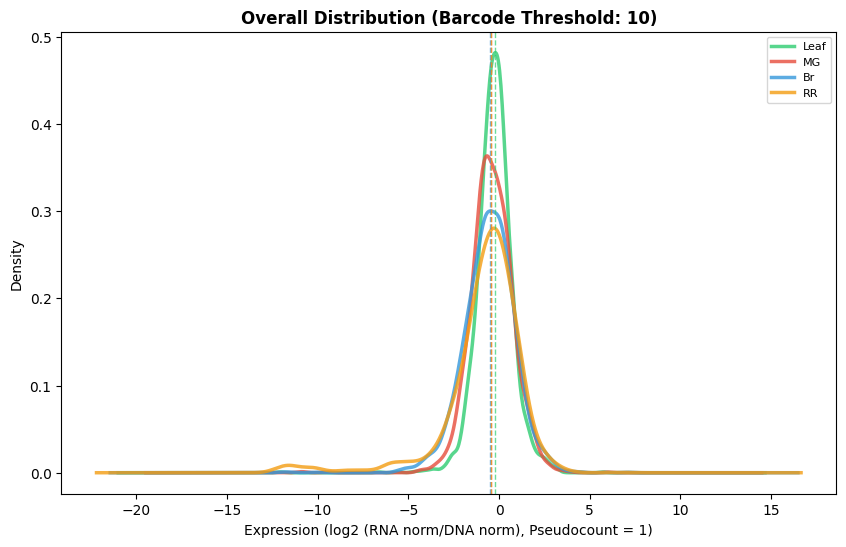

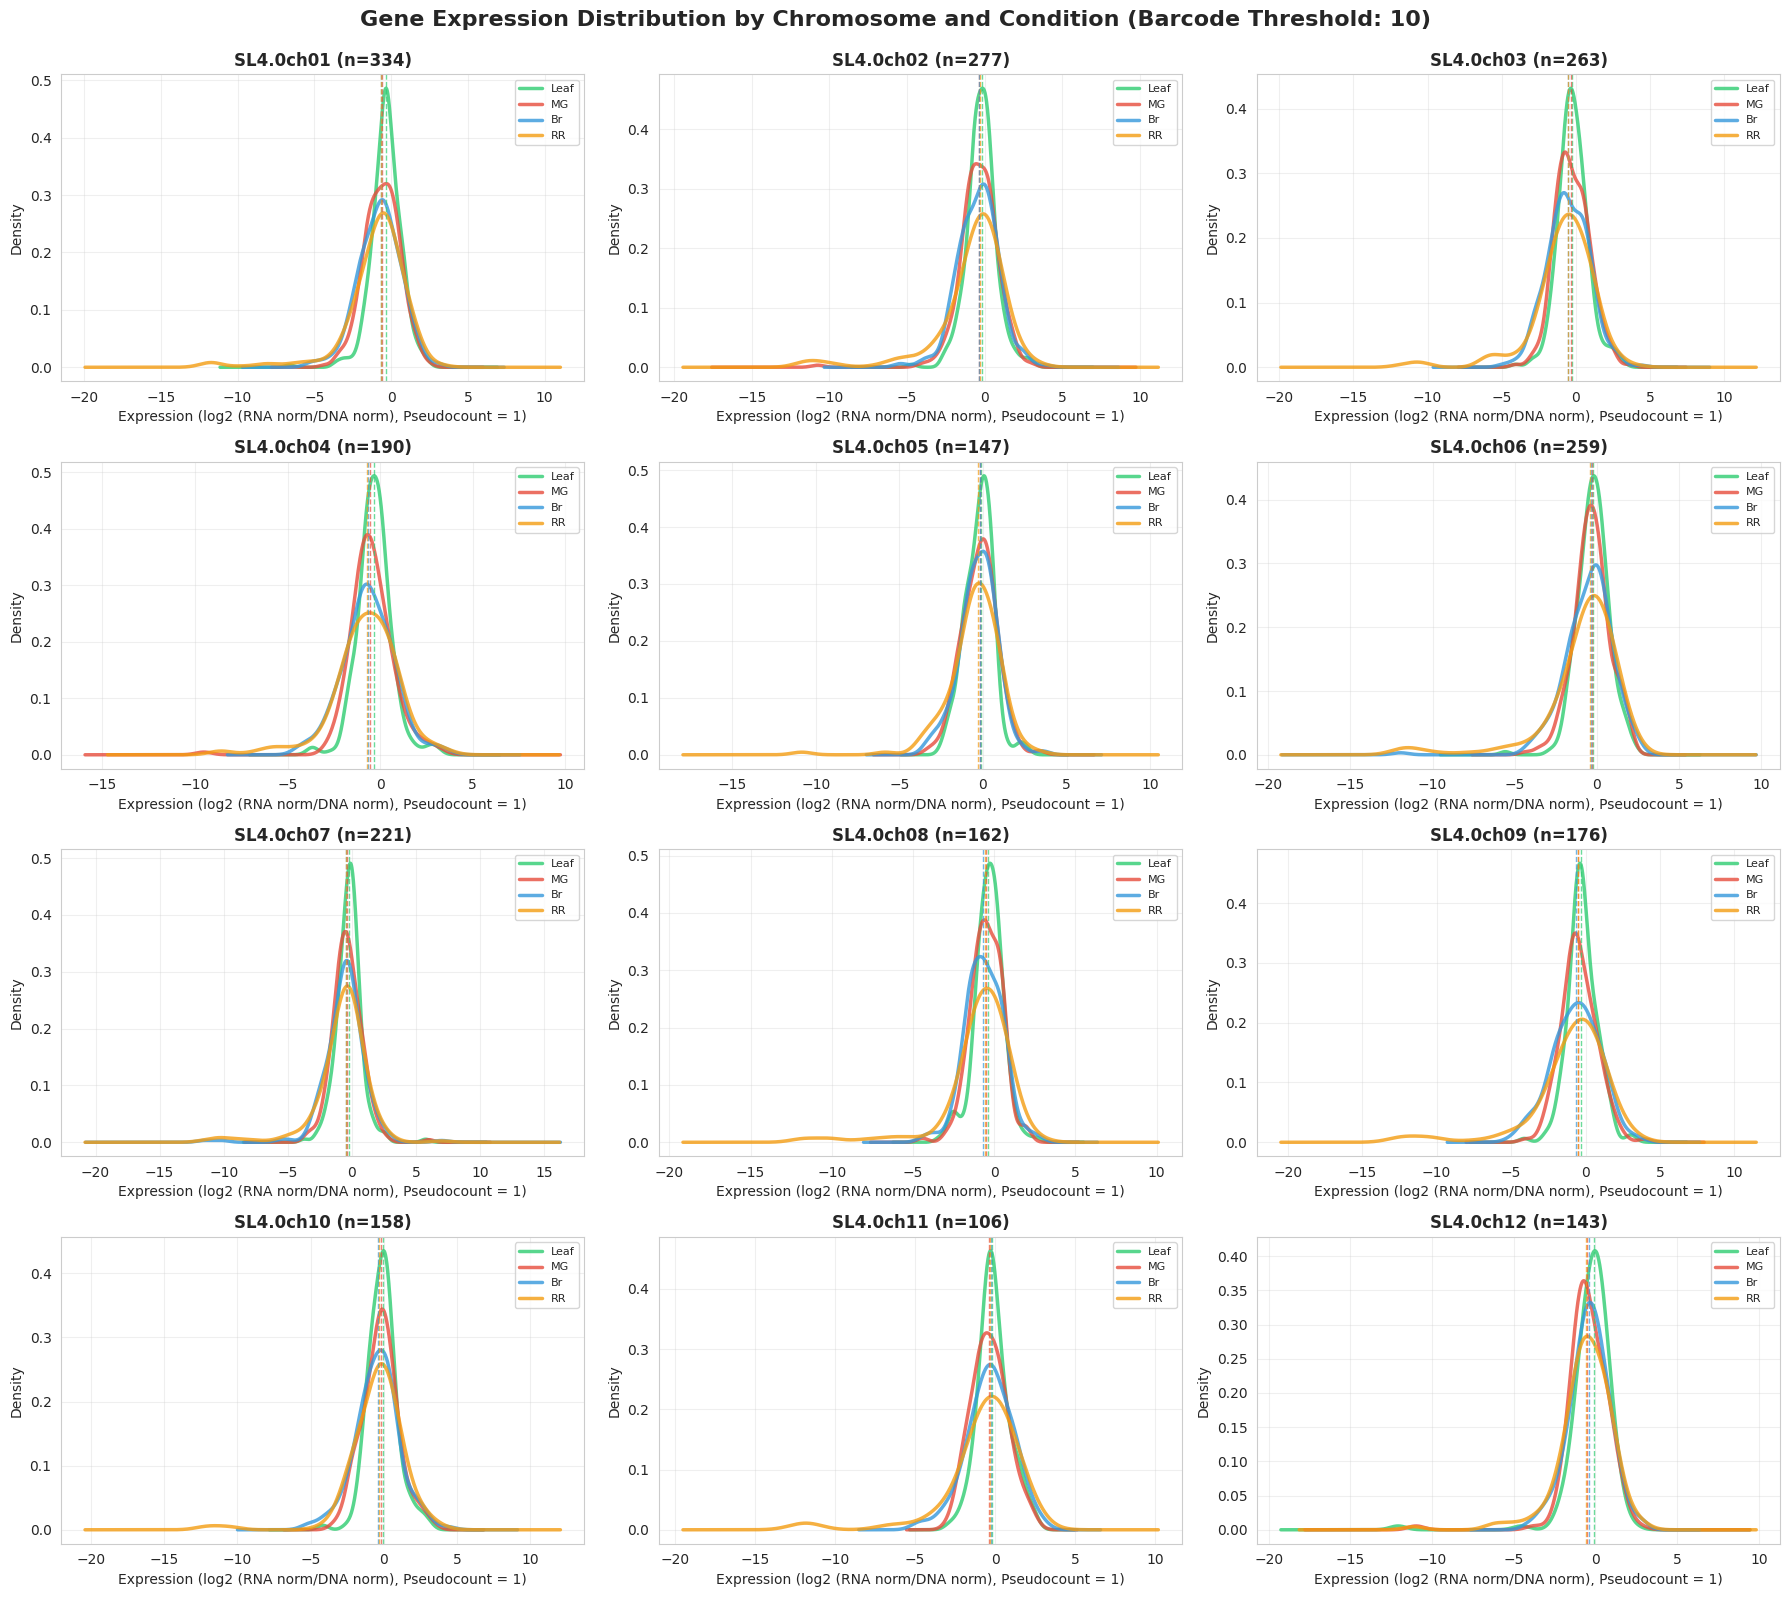

In [2]:
from data_prep import filter_threshold, split_chroms, plot__overall_distribution, plot_chrom_distributions
all_data = compute_pseudocount_log2_from_readcounts(full_readcount_file, sequences_file, metadata_path + "/full_pseudocount_log2.tsv", pseudocount=1)
barcode_threshold = 10
above_ten_thresh = filter_threshold(all_data, barcode_threshold) #start with >= 10 unique barcodes
chrom_dict, val_chrom, test_chrom, chrom_percentages = split_chroms(above_ten_thresh)

plot__overall_distribution(above_ten_thresh, barcode_threshold) #plot all the data
plot_chrom_distributions(chrom_dict, barcode_threshold)

In [3]:
from data_prep import compute_replicate_log2_activity, compute_replicate_correlations
compute_replicate_log2_activity(full_readcount_file, pseudocount=1)
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson')

Leaf: mean replicate correlation = 0.2172 (pairwise: {'1v2': np.float64(0.20777037970120624), '1v3': np.float64(0.22606139241204845), '2v3': np.float64(0.21775686084036025)})
MG: mean replicate correlation = 0.2745 (pairwise: {'1v2': np.float64(0.30149193240030625), '1v3': np.float64(0.266219648226526), '2v3': np.float64(0.2558111917989805)})
Br: mean replicate correlation = 0.3810 (pairwise: {'1v2': np.float64(0.5082433610964998), '1v3': np.float64(0.3178343077681081), '2v3': np.float64(0.3168419304939758)})
RR: mean replicate correlation = 0.4279 (pairwise: {'1v2': np.float64(0.4429174805571964), '1v3': np.float64(0.426127615558764), '2v3': np.float64(0.4146027667712498)})


{'Leaf': {'pairwise': {'1v2': np.float64(0.20777037970120624),
   '1v3': np.float64(0.22606139241204845),
   '2v3': np.float64(0.21775686084036025)},
  'mean': 0.2171962109845383},
 'MG': {'pairwise': {'1v2': np.float64(0.30149193240030625),
   '1v3': np.float64(0.266219648226526),
   '2v3': np.float64(0.2558111917989805)},
  'mean': 0.27450759080860426},
 'Br': {'pairwise': {'1v2': np.float64(0.5082433610964998),
   '1v3': np.float64(0.3178343077681081),
   '2v3': np.float64(0.3168419304939758)},
  'mean': 0.38097319978619454},
 'RR': {'pairwise': {'1v2': np.float64(0.4429174805571964),
   '1v3': np.float64(0.426127615558764),
   '2v3': np.float64(0.4146027667712498)},
  'mean': 0.42788262096240337}}

In [6]:
compute_replicate_correlations(full_readcount_file, pseudocount=1, method='pearson', min_barcodes=10)

Leaf: mean replicate correlation = 0.1897 (pairwise: {'1v2': np.float64(0.18779283130670543), '1v3': np.float64(0.20601966182095036), '2v3': np.float64(0.17528084380584433)})
MG: mean replicate correlation = 0.2497 (pairwise: {'1v2': np.float64(0.2620167209885857), '1v3': np.float64(0.26221006405995495), '2v3': np.float64(0.22475972776567194)})
Br: mean replicate correlation = 0.3870 (pairwise: {'1v2': np.float64(0.522068171250732), '1v3': np.float64(0.3008364105633719), '2v3': np.float64(0.3381999361986883)})
RR: mean replicate correlation = 0.3743 (pairwise: {'1v2': np.float64(0.3973877442699773), '1v3': np.float64(0.3555402347711868), '2v3': np.float64(0.3700149246060908)})


{'Leaf': {'pairwise': {'1v2': np.float64(0.18779283130670543),
   '1v3': np.float64(0.20601966182095036),
   '2v3': np.float64(0.17528084380584433)},
  'mean': 0.18969777897783335},
 'MG': {'pairwise': {'1v2': np.float64(0.2620167209885857),
   '1v3': np.float64(0.26221006405995495),
   '2v3': np.float64(0.22475972776567194)},
  'mean': 0.24966217093807086},
 'Br': {'pairwise': {'1v2': np.float64(0.522068171250732),
   '1v3': np.float64(0.3008364105633719),
   '2v3': np.float64(0.3381999361986883)},
  'mean': 0.38703483933759736},
 'RR': {'pairwise': {'1v2': np.float64(0.3973877442699773),
   '1v3': np.float64(0.3555402347711868),
   '2v3': np.float64(0.3700149246060908)},
  'mean': 0.37431430121575165}}